# Load data

In [1374]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE_PATH = r"C:\Users\Rasmus\OneDrive - Danmarks Tekniske Universitet\Skrivebord\S234496\6. sem\Batchler\kode\DUKAT\data"
#Folder_name = "HOLY SHIT IT MIGHT WORK (sensor 1 (049))" #test 1
#Folder_name = "data-2026-05-04-12-19-01 (sensor 1(049))" #test 2
Folder_name = "data-2026-05-04-14-00-56 (sensor 2 (76))" #test 3 #test 1 sensor 2
#Folder_name = "data-2026-05-06-15-10-09 (sensor 2 (76))" #test 4 # test 2 sensor 2

def load_csv(foldername, filename):
    path = os.path.join(BASE_PATH, foldername, filename)
    return pd.read_csv(path)

def load_and_fix(foldername, filename):
    path = os.path.join(BASE_PATH, foldername, filename)
    df = pd.read_csv(path, header=None, names=["time", "col2", "raw"])

    # Keep only valid measurement rows
    df = df[df["raw"].astype(str).str.contains(r"^(V|T2|T3|T4):")].copy()

    # Split safely
    df[["type", "value"]] = df["raw"].str.split(":", n=1, expand=True)

    rows = []
    current = {}

    for _, row in df.iterrows():
        t = row["type"]

        if t == "V":
            # Start new cycle
            if current:
                rows.append(current)
            current = {
                "V": row["value"],
                "V_time": row["time"]
            }

        elif t in ["T2", "T3", "T4"]:
            current[t] = row["value"]
            current[f"{t}_time"] = row["time"]

    # Append last one
    if current:
        rows.append(current)

    return pd.DataFrame(rows)

def decode_V(hex_str):
    if not isinstance(hex_str, str):
        return np.nan  # skip bad values

    value_hex = hex_str[-6:]

    # Optional: signed 24-bit handling (if needed)
    value = int(value_hex, 16)
    if value >= 2**23:  # negative in 24-bit signed
        value -= 2**24

    return value/2**23

#STM_data load
STM_data = load_and_fix(Folder_name, "STM_data.csv")
time_cols = ["V_time", "T2_time", "T3_time", "T4_time"]
for col in time_cols:
    STM_data[col] = STM_data[col] - STM_data[col].iloc[0]
STM_data["V"] = STM_data["V"].apply(decode_V)

temp_cols = ["T2", "T3", "T4"]
for col in temp_cols:
    STM_data[col] = -(np.sqrt(-0.00232*STM_data[col].apply(decode_V)*2000 + 17.59246) - 3.908) / 0.00116

temp_cols = ["T2", "T3", "T4"]

mask = pd.Series(True, index=STM_data.index)

for col in temp_cols + ["V"]:
    rel_change = STM_data[col].pct_change().abs()
    mask &= (rel_change <= 0.10) | rel_change.isna()

#drop rows where V is higher than 0.02 or lower than -0.002
mask &= (STM_data["V"] <= 0.02) & (STM_data["V"] >= -0.002)

#only keep rows where time is over 600 seconds
mask &= (STM_data["V_time"] >= 600)


STM_data = STM_data[mask]

#FLUKE_data load
FLUKE_data_raw = load_csv(Folder_name, "FLUKE_data.csv")
FLUKE_data_raw.columns = ["FLUKE_time", "BAR", "BAR but useless"]
FLUKE_data = FLUKE_data_raw.drop(columns=["BAR but useless"])
FLUKE_data.FLUKE_time = FLUKE_data.FLUKE_time - FLUKE_data.FLUKE_time.iloc[0]

#FLUKE and STM combine
data = pd.concat([FLUKE_data, STM_data], ignore_index=True)

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_21060\3044775064.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[df["raw"].astype(str).str.contains(r"^(V|T2|T3|T4):")].copy()
C:\Users\Rasmus\AppData\Local\Temp\ipykernel_21060\3044775064.py:80: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rel_change = STM_data[col].pct_change().abs()


In [1375]:
data

,FLUKE_time,BAR,V,V_time,T2,T2_time,T3,T3_time,T4,T4_time
0,0.000000,0.085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.079506,0.085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.168519,0.084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.255554,0.084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.351905,0.084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
73080,NaN,NaN,-0.000395,4810.845326,4.530634,4810.852307,-3.602341,4810.855410,22.768692,4810.846560
73081,NaN,NaN,-0.000394,4811.011027,4.479319,4811.021276,-3.468935,4811.020521,22.762857,4811.011516
73082,NaN,NaN,-0.000395,4811.176807,4.649090,4811.185861,-3.814354,4811.183143,22.613726,4811.174332
73083,NaN,NaN,-0.000395,4811.667834,4.625692,4811.679423,-3.271223,4811.676281,22.857634,4811.672530


In [1376]:
#synchronize data using merge_asof

import pandas as pd

# Assuming your raw dataframe is called 'data'

# 1. Ensure all time columns are actual datetime objects
data['FLUKE_time'] = pd.to_datetime(data['FLUKE_time'])
data['V_time'] = pd.to_datetime(data['V_time'])
data['T2_time'] = pd.to_datetime(data['T2_time'])
data['T3_time'] = pd.to_datetime(data['T3_time'])

# 2. Split into individual sensor DataFrames, drop empty rows, and SORT by time
# Sorting is absolutely required for merge_asof to work
df_fluke = data[['FLUKE_time', 'BAR']].dropna().sort_values('FLUKE_time')
df_v = data[['V_time', 'V']].dropna().sort_values('V_time')
df_t2 = data[['T2_time', 'T2']].dropna().sort_values('T2_time')
df_t3 = data[['T3_time', 'T3']].dropna().sort_values('T3_time')

# 3. Synchronize using merge_asof
# We will use df_v as our main "anchor" timeline.

# Merge Fluke (Pressure) onto Voltage
merged_data = pd.merge_asof(
    df_v, 
    df_fluke, 
    left_on='V_time', 
    right_on='FLUKE_time', 
    direction='nearest', # Finds the closest time, whether it's slightly before or after
    tolerance=pd.Timedelta('1s')
)

# Merge T2 onto the new dataframe
merged_data = pd.merge_asof(
    merged_data, 
    df_t2, 
    left_on='V_time', 
    right_on='T2_time', 
    direction='nearest',
    tolerance=pd.Timedelta('1s')
)

# Merge T3 onto the new dataframe
merged_data = pd.merge_asof(
    merged_data, 
    df_t3, 
    left_on='V_time', 
    right_on='T3_time', 
    direction='nearest',
    tolerance=pd.Timedelta('1s')
)

# 4. Prepare for the Least Squares Model (just like before)
merged_data['T'] = (merged_data['T2'] + merged_data['T3']) / 2
merged_data = merged_data.rename(columns={'BAR': 'P', 'V': 'V_out'})

# This is your perfectly synchronized dataset!
model_data = merged_data[['P', 'V_out', 'T']].dropna()

print(model_data)

            P     V_out          T
0      65.279  0.014706  21.123525
1      65.279  0.014706  21.123525
2      65.279  0.014706  21.123525
3      65.279  0.014705  21.123525
4      65.279  0.014706  21.123525
...       ...       ...        ...
21181   0.010 -0.000393   0.283074
21182   0.009 -0.000395   0.646823
21183   0.009 -0.000395   0.646823
21184   0.009 -0.000394   0.646823
21185   0.009 -0.000394   0.646823

[21186 rows x 3 columns]


In [ ]:
#model_data.to_csv("WHAT_DA_HELLY.csv", index=False)

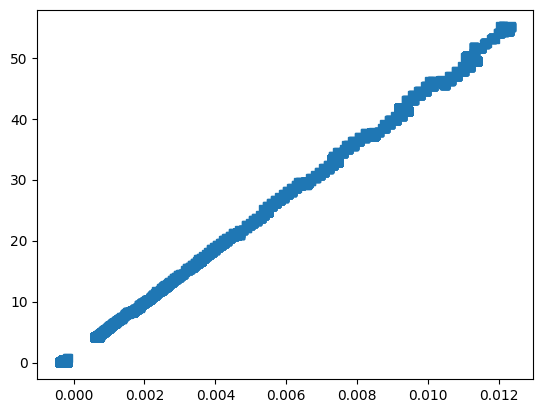

In [ ]:
model_data_1 = pd.read_csv("WHAT_DA_HELLY.csv")
model_data_2 = pd.read_csv("WHAT_DA_HELLY2.csv")

#plt.plot(model_data_1['V_out'], model_data_1['P'], 'o', label='Data Points 1')
plt.plot(model_data_2['V_out'], model_data_2['P'], 's', label='Data Points 2')

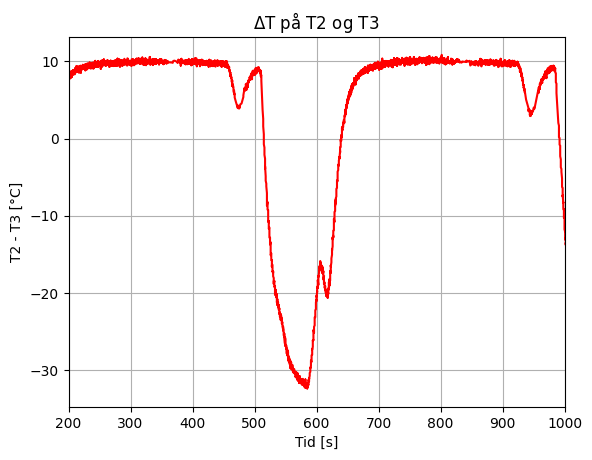

In [1339]:
#plot T2 - T3 over time
plt.plot((data["T2_time"] - data["T2_time"].min()), data["T2"] - data["T3"], color = "red")
plt.xlabel("Tid [s]")
plt.ylabel("T2 - T3 [°C]")
plt.title("$\Delta$T på T2 og T3")
plt.xlim(200, 1000)
plt.grid()
plt.savefig("delta_T.png")

In [ ]:
import numpy as np
import pandas as pd

# Assuming 'model_data' is your synchronized dataframe with 18422 rows
# Let's do one final clean to ensure NO hidden infinity values exist
#model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

# 1. Extract the columns as raw numpy arrays. 
# This strips away all Pandas indexing which is usually what crashes statsmodels.
P = model_data_1['P'].values
V = model_data_1['V_out'].values
T = model_data_1['T'].values

# 2. Build the "Design Matrix"
# Each column represents one part of your polynomial equation.
# np.ones() creates a column of 1s for the c0 intercept.
# Expanded Design Matrix for Deep Thermal Compensation
A = np.column_stack([
    np.ones(len(P)), # c0
    V,               # c1
    T,               # c2
    V * T,           # c3 (Basic Span Shift)
    #V**2,            # c4 (Pressure Non-linearity)
    #T**2,            # c5 (Thermal Zero Non-linearity)
    #(V**2) * T,      # c6 (How temp affects pressure non-linearity)
    #V * (T**2),      # c7 (Severe thermal span shifts)
    #V**3,            # c8 (3rd order pressure non-linearity)
    #T**3,             # c9 (3rd order thermal non-linearity)
    #V**2 * T**2      # c10 (Cross-term for extreme conditions)
])

# Perform the fit
coefficients, residuals, rank, singular_values = np.linalg.lstsq(A, P, rcond=None)
#c0, c1, c2, c3, c4, c5, c6, c7, c8, c9, c10 = coefficients
c0, c1, c2, c3 = coefficients

# Calculate the new estimated pressure
model_data_1['P_est'] = (
    c0 + (c1 * V) + (c2 * T) + (c3 * V * T))

print("Least Squares Fit Coefficients:")
print(f"c0 (Intercept): {c0}")
print(f"c1 (V):         {c1}")
print(f"c2 (T):         {c2}")
print(f"c3 (V*T):       {c3}")

Least Squares Fit Coefficients:
c0 (Intercept): 1.5716140134281313
c1 (V):         4217.4660153300965
c2 (T):         -0.013115838119928766
c3 (V*T):       4.232948317889243


In [1391]:
from sympy import *

T_sym, V_sym = symbols('T V')
er_du_model = coefficients[0] + coefficients[1]*V_sym + coefficients[2]*T_sym + coefficients[3]*V_sym*T_sym
latex(er_du_model)

'4.23294831788924 T V - 0.0131158381199288 T + 4217.4660153301 V + 1.57161401342813'

$$Test_1 = 4.23294831788924 T V - 0.0131158381199288 T + 4217.4660153301 V + 1.57161401342813$$
$$Test_2 = 4.4783451196447 T V - 0.0132377059499301 T + 4237.54177426006 V + 1.4816188533025 $$

In [1392]:
test1 = 4.23294831788924 * T_sym * V_sym - 0.0131158381199288 * T_sym + 4217.4660153301 * V_sym + 1.57161401342813
test2 = 4.4783451196447 * T_sym * V_sym - 0.0132377059499301 * T_sym + 4237.54177426006 * V_sym + 1.4816188533025

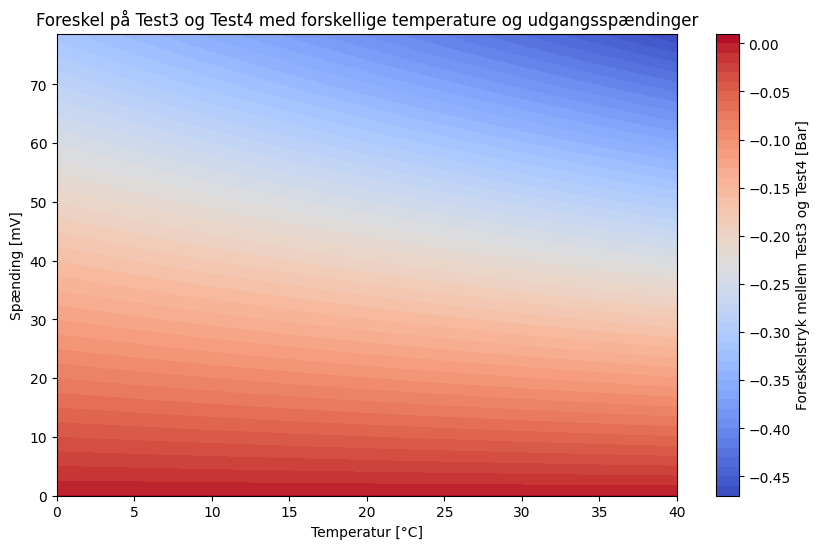

In [ ]:
#compare test1 and test2 within the relevant range of T and V
T_linspace = np.linspace(0, 40, 10000)
V_linspace = np.linspace(0, 0.01572299003 * 1000 * 5, 1000)
T_grid, V_grid = np.meshgrid(T_linspace, V_linspace)
###########################################################################################################################
test_1_grid = 4.23294831788924 * T_grid * V_grid - 0.0131158381199288 * T_grid + 4217.4660153301 * V_grid + 1.57161401342813
test_2_grid = 4.4783451196447 * T_grid * V_grid - 0.0132377059499301 * T_grid + 4237.54177426006 * V_grid + 1.4816188533025
difference_grid = (test_1_grid - test_2_grid)/5000

#plot the difference
plt.figure(figsize=(10, 6))
plt.contourf(T_grid, V_grid, difference_grid, levels=50, cmap='coolwarm')
plt.colorbar(label='Foreskelstryk mellem Test3 og Test4 [Bar]')
plt.title('Foreskel på Test3 og Test4 med forskellige temperature og udgangsspændinger')
plt.xlabel('Temperatur [°C]')
plt.ylabel('Spænding [mV]')
plt.savefig('difference_grid_with_temp_and_voltage_and_BAR.png', dpi=300)
plt.show()

# LUT

Average Error: +/- 0.6296 BAR
Model Accuracy (R2):  0.9985
Max Error: +/- 3.8330 BAR, at P=5.282 BAR and T=43.286°C


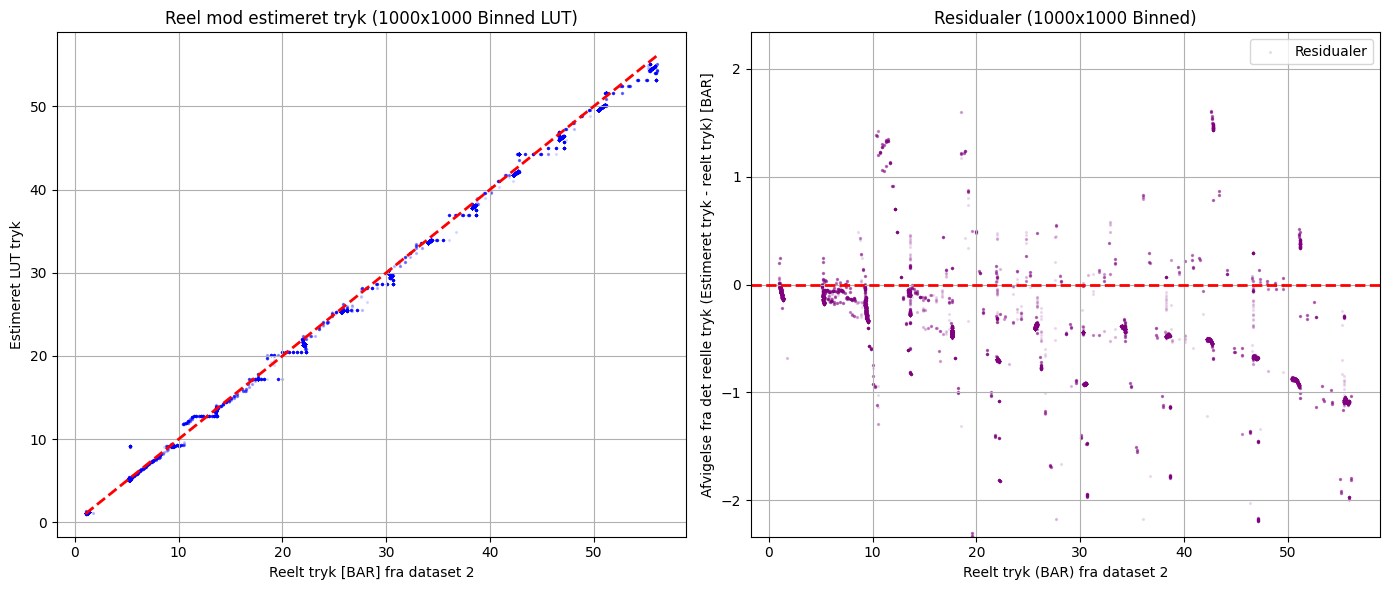

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata, RegularGridInterpolator

# tidligere datasæt
df_old = pd.read_csv('WHAT_DA_HELLY.csv').dropna()
V_old = df_old['V_out'].values * 5000
T_old = df_old['T'].values
P_old = df_old['P'].values + 1.01325  # Juster for atmosfærisk tryk

# Setup the grid with custom sizes for each axis
v_grid_size = 1000  # Size for the Voltage (V_out) axis
t_grid_size = 1000  # Size for the Temperature (T) axis

v_min, v_max = V_old.min(), V_old.max()
t_min, t_max = T_old.min(), T_old.max()

v_edges = np.linspace(v_min, v_max, v_grid_size + 1)
t_edges = np.linspace(t_min, t_max, t_grid_size + 1)

lut_binned, _, _, _ = binned_statistic_2d(
    V_old, T_old, P_old, 
    statistic='mean', 
    bins=[v_edges, t_edges]
)

# Brug knn til tommer værdier
v_centers = (v_edges[:-1] + v_edges[1:]) / 2
t_centers = (t_edges[:-1] + t_edges[1:]) / 2
V_grid, T_grid = np.meshgrid(v_centers, t_centers, indexing='ij')

V_norm = (V_old - v_min) / (v_max - v_min)
T_norm = (T_old - t_min) / (t_max - t_min)
V_grid_norm = (V_grid - v_min) / (v_max - v_min)
T_grid_norm = (T_grid - t_min) / (t_max - t_min)

lut_nearest = griddata((V_norm, T_norm), P_old, (V_grid_norm, T_grid_norm), method='nearest')
lut_final = np.where(np.isnan(lut_binned), lut_nearest, lut_binned)

# Bilinær Interpolation på modellen
bin_interpolator = RegularGridInterpolator((v_centers, t_centers), lut_final, method='linear')

########################################
# load model data
df_new = pd.read_csv('WHAT_DA_HELLY2.csv').dropna()
V_new = df_new['V_out'].values * 1000
T_new = df_new['T'].values
P_new_true = df_new['P'].values + 1.01325

# CLIP lut
v_clipped = np.clip(V_new, v_centers[0], v_centers[-1])
t_clipped = np.clip(T_new, t_centers[0], t_centers[-1])
pts_new = np.column_stack([v_clipped, t_clipped])

# Model forudsigelser
P_new_est = bin_interpolator(pts_new)
model_data = pd.DataFrame({'P': P_new_true, 'V': V_new, 'T': T_new, 'P_est': P_new_est})

########################################
# udregn fejl
model_data['Error'] = model_data['P_est'] - model_data['P']

mse = np.mean(model_data['Error']**2)
rmse = np.sqrt(mse)

ss_res = np.sum(model_data['Error']**2)
ss_tot = np.sum((model_data['P'] - np.mean(model_data['P']))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"Average Error: +/- {rmse:.4f} BAR")
print(f"Model Accuracy (R2):  {r2:.4f}")
print(f"Max Error: +/- {np.max(np.abs(model_data['Error'])):.4f} BAR, at P={model_data['P'][np.argmax(np.abs(model_data['Error']))]:.3f} BAR and T={model_data['T'][np.argmax(np.abs(model_data['Error']))]:.3f}°C")

###########################################
# Plots
plt.figure(figsize=(14, 6))

# Reel vs. Estimeret tryk
plt.subplot(1, 2, 1)
plt.scatter(model_data['P'], model_data['P_est'], alpha=0.1, s=2, color='blue', label='interpolerede datapunkter')

min_val = min(model_data['P'].min(), model_data['P_est'].min())
max_val = max(model_data['P'].max(), model_data['P_est'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title(f'Reel mod estimeret tryk ({v_grid_size}x{t_grid_size} Binned LUT)')
plt.xlabel('Reelt tryk [BAR] fra dataset 2')
plt.ylabel('Estimeret LUT tryk')
plt.grid(True)

# Residualer
plt.subplot(1, 2, 2)
plt.scatter(model_data['P'], model_data['Error'], alpha=0.1, s=2, color='purple', label='Residualer')

plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.legend()
plt.title(f'Residualer ({v_grid_size}x{t_grid_size} Binned)')
plt.xlabel('Reelt tryk (BAR) fra dataset 2')
plt.ylabel('Afvigelse fra det reelle tryk (Estimeret tryk - reelt tryk) [BAR]')
plt.ylim([-2.3363 , 2.3363]) 
plt.grid(True)
plt.savefig('residuals_plot_binned_model_on_new_data.png', dpi=300)

plt.tight_layout()
plt.show()

Starting grid search... This might take a moment depending on the range.

GRID SEARCH COMPLETE
Best V_out Grid Size: 39
Best T Grid Size:     2
Lowest Average Error: +/- 0.4144 BAR
Corresponding R2:     0.9994


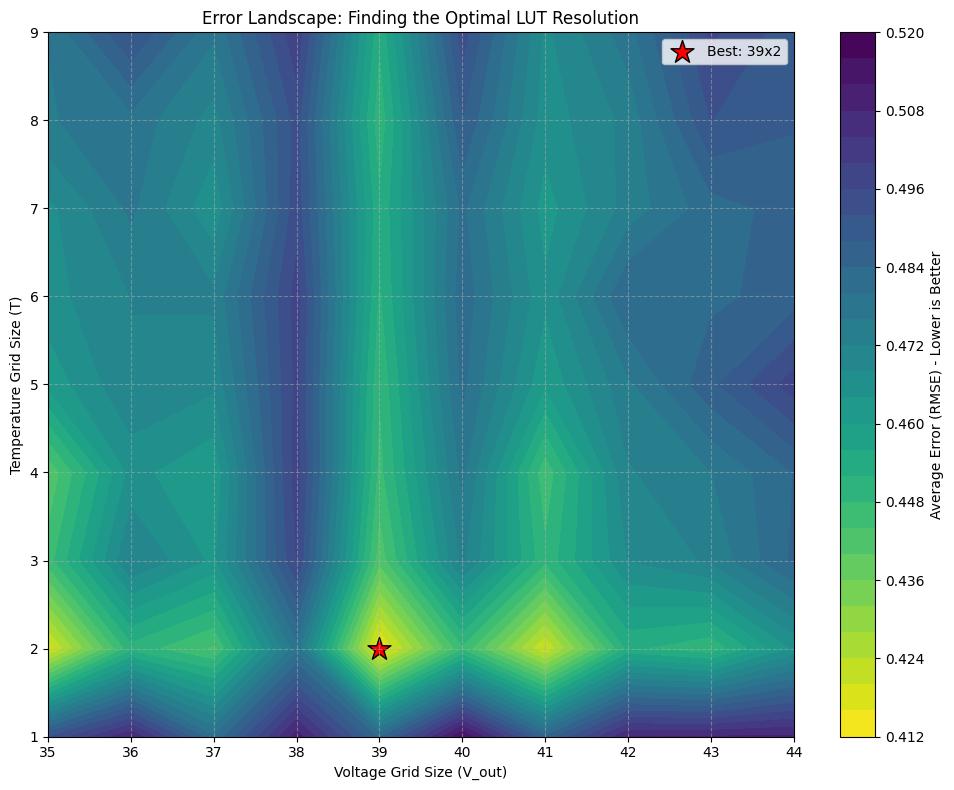

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata, RegularGridInterpolator

#Load data
df_old = pd.read_csv('WHAT_DA_HELLY.csv').dropna()
V_old = df_old['V_out'].values * 5000
T_old = df_old['T'].values
P_old = df_old['P'].values + 1.01325

df_new = pd.read_csv('WHAT_DA_HELLY2.csv').dropna()
V_new = df_new['V_out'].values * 5000
T_new = df_new['T'].values
P_new_true = df_new['P'].values + 1.01325

# Min/Max values for dataset 1
v_min, v_max = V_old.min(), V_old.max()
t_min, t_max = T_old.min(), T_old.max()

# test size
v_sizes_to_test = range(35, 45, 1)
t_sizes_to_test = range(1, 10, 1)

# Variables to track the best performing setup
best_rmse = float('inf')
best_v_size = None
best_t_size = None
best_r2 = None
results = []

# loop through all combinations
for v_size in v_sizes_to_test:
    for t_size in t_sizes_to_test:
        
        # Grid
        v_edges = np.linspace(v_min, v_max, v_size + 1)
        t_edges = np.linspace(t_min, t_max, t_size + 1)

        # Bin
        lut_binned, _, _, _ = binned_statistic_2d(
            V_old, T_old, P_old, 
            statistic='mean', 
            bins=[v_edges, t_edges]
        )

        v_centers = (v_edges[:-1] + v_edges[1:]) / 2
        t_centers = (t_edges[:-1] + t_edges[1:]) / 2
        V_grid, T_grid = np.meshgrid(v_centers, t_centers, indexing='ij')

        V_norm = (V_old - v_min) / (v_max - v_min)
        T_norm = (T_old - t_min) / (t_max - t_min)
        V_grid_norm = (V_grid - v_min) / (v_max - v_min)
        T_grid_norm = (T_grid - t_min) / (t_max - t_min)

        lut_nearest = griddata((V_norm, T_norm), P_old, (V_grid_norm, T_grid_norm), method='nearest')
        lut_final = np.where(np.isnan(lut_binned), lut_nearest, lut_binned)

        # Interpolator
        bin_interpolator = RegularGridInterpolator((v_centers, t_centers), lut_final, method='linear')

        # Test på Dataset 2
        v_clipped = np.clip(V_new, v_centers[0], v_centers[-1])
        t_clipped = np.clip(T_new, t_centers[0], t_centers[-1])
        pts_new = np.column_stack([v_clipped, t_clipped])

        P_new_est = bin_interpolator(pts_new)
        
        # afvigelser
        errors = P_new_est - P_new_true
        rmse = np.sqrt(np.mean(errors**2))
        
        ss_res = np.sum(errors**2)
        ss_tot = np.sum((P_new_true - np.mean(P_new_true))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # gem resultater
        results.append({'v_size': v_size, 't_size': t_size, 'rmse': rmse, 'r2': r2})

        # tjek om det er den bedste model
        if rmse < best_rmse:
            best_rmse = rmse
            best_v_size = v_size
            best_t_size = t_size
            best_r2 = r2

# Print results
print("\n" + "=" * 30)
print("GRID SEARCH COMPLETE")
print("=" * 30)
print(f"Best V_out Grid Size: {best_v_size}")
print(f"Best T Grid Size:     {best_t_size}")
print(f"Lowest Average Error: +/- {best_rmse:.4f} BAR")
print(f"Corresponding R2:     {best_r2:.4f}")

# Plot a heatmap
results_df = pd.DataFrame(results)
rmse_pivot = results_df.pivot(index='t_size', columns='v_size', values='rmse')

plt.figure(figsize=(10, 8))
contour = plt.contourf(rmse_pivot.columns, rmse_pivot.index, rmse_pivot.values, levels=30, cmap='viridis_r')
plt.colorbar(contour, label='Average Error (RMSE) - Lower is Better')
plt.scatter([best_v_size], [best_t_size], color='red', marker='*', s=300, edgecolor='black', label=f'Best: {best_v_size}x{best_t_size}')
plt.title('Error Landscape: Finding the Optimal LUT Resolution')
plt.xlabel('Voltage Grid Size (V_out)')
plt.ylabel('Temperature Grid Size (T)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Average Error: +/- 0.4144 BAR
Model Accuracy (R2):  0.9994
Max Error: +/- 1.6789 BAR, at P=56.143 BAR and T=0.702°C


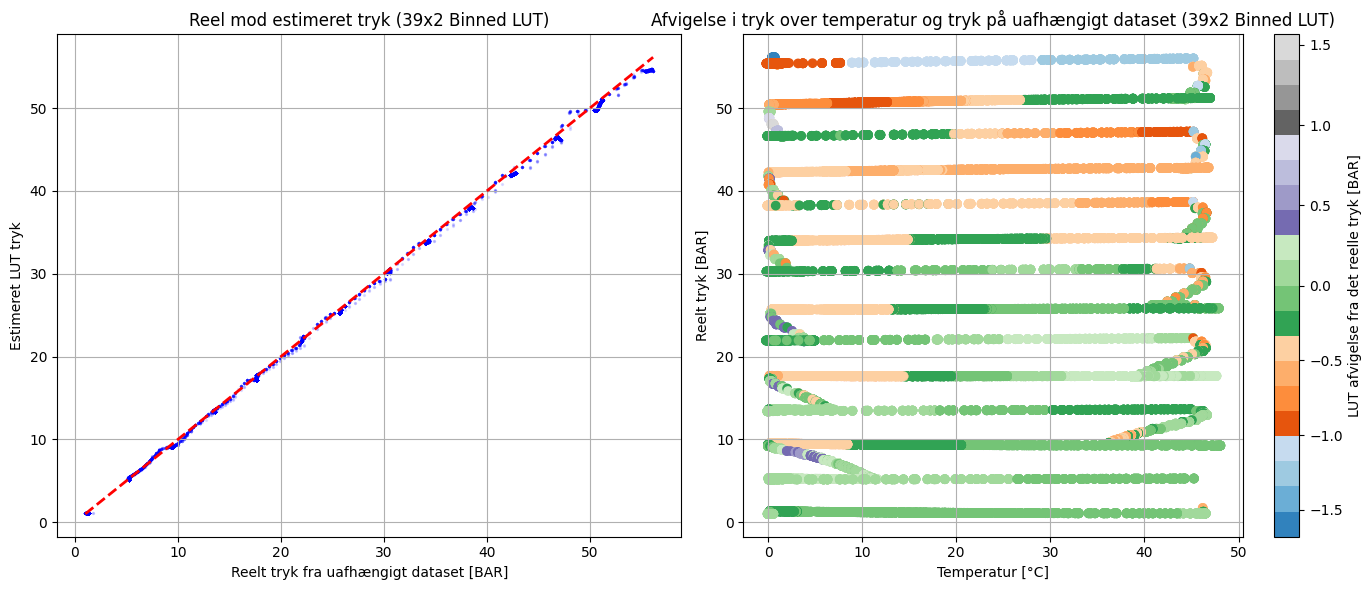

In [1416]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata, RegularGridInterpolator

# tidligere datasæt
df_new = pd.read_csv('WHAT_DA_HELLY2.csv').dropna()
df_old = pd.read_csv('WHAT_DA_HELLY.csv').dropna()

#df_old = pd.read_csv('WHAT_DA_HELLY.csv').dropna()
V_old = df_old['V_out'].values * 5000
T_old = df_old['T'].values
P_old = df_old['P'].values + 1.01325  # Juster for atmosfærisk tryk

# Setup the grid with custom sizes for each axis
v_grid_size = 39  # Indstil din custom størrelse her (f.eks. 20)
t_grid_size = 2  # Indstil din custom størrelse her (f.eks. 30)

v_min, v_max = V_old.min(), V_old.max()
t_min, t_max = T_old.min(), T_old.max()

v_edges = np.linspace(v_min, v_max, v_grid_size + 1)
t_edges = np.linspace(t_min, t_max, t_grid_size + 1)

lut_binned, _, _, _ = binned_statistic_2d(
    V_old, T_old, P_old, 
    statistic='mean', 
    bins=[v_edges, t_edges]
)

# Brug knn til tommer værdier
v_centers = (v_edges[:-1] + v_edges[1:]) / 2
t_centers = (t_edges[:-1] + t_edges[1:]) / 2
V_grid, T_grid = np.meshgrid(v_centers, t_centers, indexing='ij')

V_norm = (V_old - v_min) / (v_max - v_min)
T_norm = (T_old - t_min) / (t_max - t_min)
V_grid_norm = (V_grid - v_min) / (v_max - v_min)
T_grid_norm = (T_grid - t_min) / (t_max - t_min)

lut_nearest = griddata((V_norm, T_norm), P_old, (V_grid_norm, T_grid_norm), method='nearest')
lut_final = np.where(np.isnan(lut_binned), lut_nearest, lut_binned)

# Bilinær Interpolation på modellen
bin_interpolator = RegularGridInterpolator((v_centers, t_centers), lut_final, method='linear')

########################################
# load model data
#df_new = pd.read_csv('WHAT_DA_HELLY2.csv').dropna()
V_new = df_new['V_out'].values * 5000
T_new = df_new['T'].values
P_new_true = df_new['P'].values + 1.01325

# CLIP lut
v_clipped = np.clip(V_new, v_centers[0], v_centers[-1])
t_clipped = np.clip(T_new, t_centers[0], t_centers[-1])
pts_new = np.column_stack([v_clipped, t_clipped])

# Model forudsigelser
P_new_est = bin_interpolator(pts_new)
model_data = pd.DataFrame({'P': P_new_true, 'V': V_new, 'T': T_new, 'P_est': P_new_est})

########################################
# udregn fejl
model_data['Error'] = model_data['P_est'] - model_data['P']

mse = np.mean(model_data['Error']**2)
rmse = np.sqrt(mse)

ss_res = np.sum(model_data['Error']**2)
ss_tot = np.sum((model_data['P'] - np.mean(model_data['P']))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"Average Error: +/- {rmse:.4f} BAR")
print(f"Model Accuracy (R2):  {r2:.4f}")
print(f"Max Error: +/- {np.max(np.abs(model_data['Error'])):.4f} BAR, at P={model_data['P'][np.argmax(np.abs(model_data['Error']))]:.3f} BAR and T={model_data['T'][np.argmax(np.abs(model_data['Error']))]:.3f}°C")

###########################################
# Plots
plt.figure(figsize=(14, 6))

# Reel vs. Estimeret tryk
plt.subplot(1, 2, 1)
plt.scatter(model_data['P'], model_data['P_est'], alpha=0.1, s=2, color='blue', label='interpolerede datapunkter')

min_val = min(model_data['P'].min(), model_data['P_est'].min())
max_val = max(model_data['P'].max(), model_data['P_est'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title(f'Reel mod estimeret tryk ({v_grid_size}x{t_grid_size} Binned LUT)')
plt.xlabel('Reelt tryk fra uafhængigt dataset [BAR]')
plt.ylabel('Estimeret LUT tryk')
plt.grid(True)

# Residualer
plt.subplot(1, 2, 2)
from matplotlib.colors import Normalize, TwoSlopeNorm
maxx = model_data["Error"].max()
minn = model_data["Error"].min()

norm = TwoSlopeNorm(vmin=minn, vcenter=0, vmax=maxx)
plt.scatter(T_new, model_data["P"], c=model_data['Error'], cmap='tab20c', norm=norm)
plt.colorbar(label='LUT afvigelse fra det reelle tryk [BAR]')
plt.title(f'Afvigelse i tryk over temperatur og tryk på uafhængigt dataset ({v_grid_size}x{t_grid_size} Binned LUT)')
plt.xlabel('Temperatur [°C]')
plt.ylabel('Reelt tryk [BAR]')
plt.grid(True)
plt.savefig('residuals_plot_binned_model_on_new_data.png', dpi=300)

plt.tight_layout()
plt.show()

In [ ]:
#lut_final

array([[12.30764389, 10.76270609],
       [12.31276989, 10.76270609],
       [12.31372356, 10.76270609],
       ...,
       [-0.19852626, 10.76270609],
       [-0.19852626, 10.76270609],
       [-0.19852626, 10.76270609]])

# FITTING ONTO A FUNCTION

Funktion RMSE: +/- 0.2524 BAR


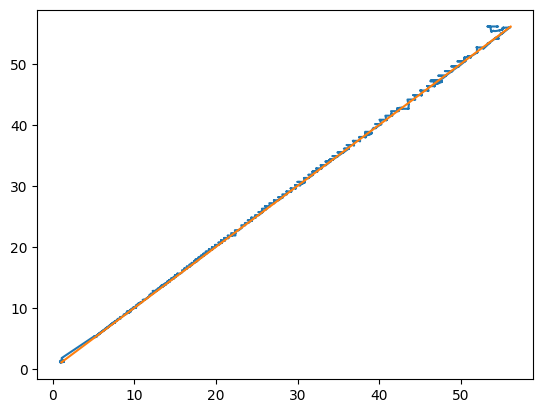

In [1417]:
#funktion = 0.9951467313480378 * model_data['P_est'] + 0.00014602744957819397 * (5*model_data['V'])**2
#load data from csv
U_0 = -0.511 * 5# mV/V@FS
U_FS = 15.406 * 5# mV/V
alpha = -1123.379 * 10**-6#ppm/C
offset = 4.180 * 1e-3 * 5  #muV/V/C

model_data = pd.read_csv('WHAT_DA_HELLY2.csv')
model_data['P'] = model_data['P'] + 1.01325

old_funktion = (model_data['V_out']*1000*5 - U_0 - offset * (model_data['T'] - 25))/((U_FS - U_0) * (1 + alpha * (model_data['T'] - 25))) * 68.9476 #+ 1.01325

plt.plot(old_funktion, model_data['P'])
plt.plot(model_data['P'], model_data['P'])
#plt.legend(['Funktion', 'Model', 'Perfect'])



residuals_funktion = old_funktion - model_data['P']
#residuals_model = model_data['P_est'] - model_data['P']

print(f"Funktion RMSE: +/- {np.sqrt(np.mean(residuals_funktion**2)):.4f} BAR")

Average Error: +/- 0.1498 BAR
Max Error: +/- 0.9610 BAR, at P=56.143 BAR and T=0.702°C


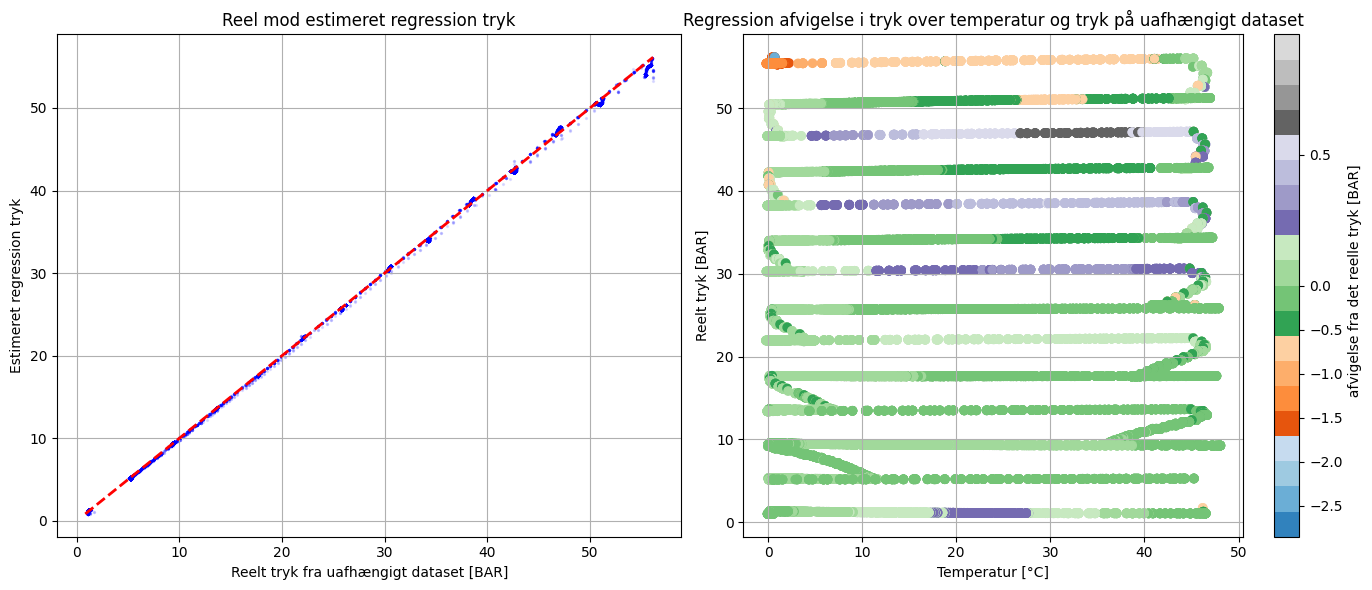

In [1411]:
residuals_funktion = old_funktion - model_data['P']

print(f"Average Error: +/- {np.mean(np.abs(residuals_funktion)):.4f} BAR")
print(f"Max Error: +/- {residuals_funktion.max():.4f} BAR, at P={model_data['P'][np.argmax(np.abs(residuals_funktion))]:.3f} BAR and T={model_data['T'][np.argmax(np.abs(residuals_funktion))]:.3f}°C")
# 
# Plots
plt.figure(figsize=(14, 6))

# Reel vs. Estimeret tryk
plt.subplot(1, 2, 1)
plt.scatter(model_data['P'], old_funktion, alpha=0.1, s=2, color='blue', label='interpolerede datapunkter')

min_val = min(model_data['P'].min(), old_funktion.min())
max_val = max(model_data['P'].max(), old_funktion.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title(f'Reel mod estimeret regression tryk')
plt.xlabel('Reelt tryk fra uafhængigt dataset [BAR]')
plt.ylabel('Estimeret regression tryk')
plt.grid(True)

# Residualer
plt.subplot(1, 2, 2)
from matplotlib.colors import Normalize, TwoSlopeNorm
maxx = residuals_funktion.max()
minn = residuals_funktion.min()

norm = TwoSlopeNorm(vmin=minn, vcenter=0, vmax=maxx)
plt.scatter(model_data['T'], model_data["P"], c=residuals_funktion, cmap='tab20c', norm=norm)
plt.colorbar(label='  afvigelse fra det reelle tryk [BAR]')
plt.title(f'Regression afvigelse i tryk over temperatur og tryk på uafhængigt dataset')
plt.xlabel('Temperatur [°C]')
plt.ylabel('Reelt tryk [BAR]')
plt.grid(True)
plt.savefig('residuals_plot_linær', dpi=300)

plt.tight_layout()
plt.show()